In [392]:
import numpy as np
from scipy.integrate import quad, dblquad
from scipy.optimize import minimize_scalar
from functools import lru_cache
import matplotlib.pyplot as plt
from scipy.special import erf
import emcee

# Distance integrals

First, let's start out with the distance integrals to make sure that the mathematical framework I am using checks out.

In [305]:
def ln_posterior_r_given_pomega(r, pomega, sig_pomega, L=200):
    '''Calculate the posterior probability: p(r|pomega)
    
    One of the quantities you need is the uncertainty in pomega.
    The length scale for the prior is also needed. By default, it is given as 200 parsecs.'''
    try:
        prob = ln_likelihood_pomega_given_r(r, pomega, sig_pomega) + ln_prior_r(r, L) - ln_norm_pomega_mobile(pomega, sig_pomega, L)
    except ZeroDivisionError:
        prob = -np.inf
    return prob

In [ ]:
def ln_likelihood_pomega_given_r(r, pomega, sig_pomega):
    '''Return the likelihood of pomega given r.
    
    This is a Gaussian centered around 1/r.'''
    ln_prob = -(pomega-1/r)**2/2/sig_pomega**2 - np.log(2*np.pi*sig_pomega**2) / 2
    return ln_prob

In [ ]:
def ln_prior_r(r, L):
    '''Return the exponentally decreasing prior for r given a length scale L'''
    if r > 0:
        ln_prob = -r/L + 2 * np.log(r) - np.log(2 * L**3)
    else:
        ln_prob = -np.inf
    return ln_prob

In [320]:
def ln_norm_pomega_mobile(pomega, sig_pomega, L):
    '''Return the normalization constant for a given pomega.'''
    prob, err = quad(lambda rr: np.exp(ln_likelihood_pomega_given_r(rr, pomega, sig_pomega)) * np.exp(ln_prior_r(rr, L)), 0, np.inf)
    return np.log(prob)

def ln_norm_pomega(pomega, sig_pomega, L):
    '''Return the normalization constant for a given pomega.'''
    coeff = 1 / np.sqrt(np.pi) / L**3 / 2
    
    lower_lim = - pomega / np.sqrt(2) / sig_pomega
    
    def r(u):
        return 1 / (pomega + np.sqrt(2) * sig_pomega * u)
    
    def integrand(u):
        return np.exp(-u**2) * r(u)**4 * np.exp(-r(u) / L)
    
    prob, err = quad(integrand, lower_lim, np.inf)
    return np.log(coeff * prob)

/Users/gsimonian/miniconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:5: RuntimeWarning: divide by zero encountered in double_scalars
  """


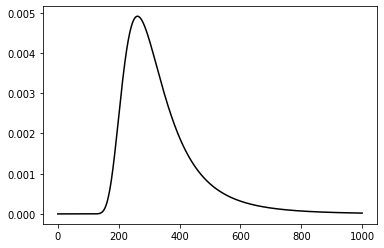

In [306]:
r_array = np.linspace(0, 1000, 1000)
p_array = np.zeros(1000)

measured_pomega = 1/250
sig_pomega = 0.001

for i, r in enumerate(r_array):
    prob = np.exp(ln_posterior_r_given_pomega(r, measured_pomega, sig_pomega, L=200))
    p_array[i] = prob
    
plt.plot(r_array, p_array, 'k-')

In [307]:
mean = quad(lambda rr: rr * np.exp(ln_posterior_r_given_pomega(rr, measured_pomega, sig_pomega, L=200)), -np.inf, np.inf)[0]
median = minimize_scalar(lambda r: abs(quad(lambda rr: np.exp(ln_posterior_r_given_pomega(rr, measured_pomega, sig_pomega, L=200)), -np.inf, r)[0] - 0.5), bracket=(0.9/measured_pomega, 1.1/measured_pomega)).x
mode = minimize_scalar(lambda rr: -ln_posterior_r_given_pomega(rr, measured_pomega, sig_pomega, L=200)).x

/Users/gsimonian/miniconda3/envs/astroconda/lib/python3.6/site-packages/scipy/optimize/optimize.py:2371: RuntimeWarning: invalid value encountered in double_scalars
  w = xb - ((xb - xc) * tmp2 - (xb - xa) * tmp1) / denom


In [308]:
print(mean)
print(median)
print(mode)

337.162986244564
304.82917906001
261.84034314256223


## Absolute magnitude

Now let's do the full calculation for the absolute magnitude.

In [346]:
def ln_posterior_Mk_given_K_pomega_Ak(Mk, K, pomega, sig_K, sig_pomega, Ak=0.0, L=200):
    '''Calculate the posterior probability of absolute K-band magnitude.'''
    ln_prob = (
        ln_norm_K_pomega_given_Mk(K, pomega, Mk, sig_K, sig_pomega, Ak, L) + ln_prior_Mk(Mk) - 
        ln_norm_K_pomega(K, pomega, sig_K, sig_pomega, Ak, L))
    return ln_prob

In [331]:
def ln_likelihood_K_pomega_given_Mk_r_Ak(K, pomega, Mk, r, sig_K, sig_pomega, Ak):
    '''Return the likelihood of K and pomega given Mk, r, and Ak.'''
    ln_prob = ln_likelihood_K_given_Mk_r_Ak(K, Mk, r, sig_K, Ak) + ln_likelihood_pomega_given_r(r, pomega, sig_pomega)
    return ln_prob

In [332]:
def ln_likelihood_K_given_Mk_r_Ak(K, Mk, r, sig_K, Ak):
    '''Return the likelihood of K given Mk, r, and Ak.
    
    Note that this treatment assumes that K and pomega are independent, which is correct in this case.'''
    ln_prob = -(K - (Mk + 5 * np.log10(r) - 5 + Ak))**2 / 2 / sig_K**2 - np.log(2 * np.pi * sig_K**2) / 2
    return ln_prob

In [24]:
lum_MK = -7.5
dim_MK = 9.5
def ln_prior_Mk(Mk):
    '''Return a uniform prior in Mk.'''
    if Mk > lum_MK and Mk < dim_MK:
        ln_prob = -np.log(dim_MK - lum_MK)
    else:
        ln_prob = -np.inf
    return ln_prob 

In [210]:
def ln_norm_K_mobile(K, sig_K, Ak, L):
    '''Calculate the marginal likelihood of K.'''
    def MK_center(r):
        calc_cen = K - 5 * np.log10(r) + 5 - Ak
        if calc_cen < lum_MK:
            MKcen = lum_MK
        elif calc_cen > dim_MK:
            MKcen = dim_MK
        else:
            MKcen = calc_cen
        return MKcen
    
     # A helper function to make the integral easier to evaluate.
    def test(MkMk, rr, K, sig_K, Ak, L):
        ln_likelihood_prob = ln_likelihood_K_given_Mk_r_Ak(K, MkMk, rr, sig_K, Ak)
        ln_prior_r_prob = ln_prior_r(rr, L)
        ln_prior_Mk_prob = ln_prior_Mk(MkMk)
        prob = ln_likelihood_prob + ln_prior_r_prob + ln_prior_Mk_prob
        print(np.exp(prob))
        return np.exp(prob)
    
    prob1, err1 = dblquad(
        test, 0, np.inf, lum_MK, MK_center, args=(K, sig_K, Ak, L))
    prob2, err2 = dblquad(
        test, 0, np.inf, MK_center, dim_MK, args=(K, sig_K, Ak, L))
    total_prob = prob1 + prob2
    print("Prob 1: {0:.2g}; Err 1 {1:.2g}".format(prob1, err1))
    print("Prob 2: {0:.2g}; Err 2 {1:.2g}".format(prob2, err2))
    return np.log(total_prob)

@lru_cache(maxsize=64)
def ln_norm_K(K, sig_K, Ak, L):
    '''Calculate the marginalized likelihood of K.
    
    Note that this calculation is explicitly optimized for a flat MK prior and the exponentially
    decreasing prior, and needs to be adjusted for any function changes.'''
    coeff = 1 / (dim_MK - lum_MK) / 4
    upper_break = 10**((K - dim_MK + 5 - Ak)/5) / L
    lower_break = 10**((K - lum_MK + 5 - Ak)/5) / L
    
    prob, err = quad(
        lambda v: v**2 * np.exp(-v) * (
            erf((dim_MK - K + 5 * np.log10(v * L) - 5 + Ak) / (np.sqrt(2) * sig_K)) -
            erf((lum_MK - K + 5 * np.log10(v * L) - 5 + Ak) / (np.sqrt(2) * sig_K))), 0, np.inf)
    return np.log(coeff * prob)

In [334]:
def ln_norm_K_pomega_mobile(K, pomega, sig_K, sig_pomega, Ak, L):
    '''Calculate the marginal likelihood of K and pomega.'''
    def MK_center(r):
        calc_cen = K - 5 * np.log10(r) + 5 - Ak
        if calc_cen < lum_MK:
            MKcen = lum_MK
        elif calc_cen > dim_MK:
            MKcen = dim_MK
        else:
            MKcen = calc_cen
        return MKcen
    if pomega > 0:
        r_center = 1 / pomega
    else:
        r_center = 0    
    
    # A helper function to make the integral easier to evaluate.
    def test(MkMk, rr, K, pomega, sig_K, sig_pomega, Ak, L):
        ln_likelihood_prob = ln_likelihood_K_pomega_given_Mk_r_Ak(K, pomega, MkMk, rr, sig_K, sig_pomega, Ak)
        ln_prior_r_prob = ln_prior_r(rr, L)
        ln_prior_Mk_prob = ln_prior_Mk(MkMk)
        prob = ln_likelihood_prob + ln_prior_r_prob + ln_prior_Mk_prob
        return np.exp(prob)
    
    prob1, err1 = dblquad(
        test, r_center, np.inf, lum_MK, MK_center, args=(K, pomega, sig_K, sig_pomega, Ak, L))
    prob2, err2 = dblquad(
        test, 0, r_center, lum_MK, MK_center, args=(K, pomega, sig_K, sig_pomega, Ak, L))
    prob3, err3 = dblquad(
        test, r_center, np.inf, MK_center, dim_MK, args=(K, pomega, sig_K, sig_pomega, Ak, L))
    prob4, err4 = dblquad(
        test, 0, r_center, MK_center, dim_MK, args=(K, pomega, sig_K, sig_pomega, Ak, L))
    total_prob = prob1 + prob2 + prob3 + prob4
    return np.log(total_prob)

@lru_cache(maxsize=64)
def ln_norm_K_pomega(K, pomega, sig_K, sig_pomega, Ak, L):
    '''Calculate the marginal likelihood of K and pomega.'''
    coeff = 1 / 4 / (dim_MK - lum_MK) / L**3 / np.sqrt(np.pi)
    
    lower_lim = - pomega / np.sqrt(2) / sig_pomega
    
    
    def r(u):
        return 1 / (pomega + np.sqrt(2) * sig_pomega * u)
    
    prob, err = quad(
        lambda u: np.exp(-u**2) * r(u)**4 * np.exp(-r(u) / L) *
            (erf((dim_MK - K + 5 * np.log10(r(u)) - 5 + Ak) / (np.sqrt(2) * sig_K)) -
            erf((lum_MK - K + 5 * np.log10(r(u)) - 5 + Ak) / (np.sqrt(2) * sig_K))), lower_lim, np.inf)
    return np.log(coeff * prob)
    

In [298]:
def ln_norm_K_pomega_given_Mk(K, pomega, Mk, sig_K, sig_pomega, Ak, L):
    '''Calculate the marginal likelihood of K and pomega given Mk'''
    coeff = 1 / np.sqrt(2) / np.pi / sig_K / L**3 / 2
    
    lower_lim = - pomega / np.sqrt(2) / sig_pomega
    
    ubreak = (10**(-(K - Mk + 5 - Ak) / 5) - pomega) / np.sqrt(2) / sig_pomega
    
    def r(u):
        return 1 / (pomega + np.sqrt(2) * sig_pomega * u)
    
    def integrand(u):
        return np.exp(-u**2) * r(u)**4 * np.exp(-r(u) / L) * \
            np.exp(-(Mk - K + 5 * np.log10(r(u)) - 5 + Ak)**2 / (2 * sig_K**2))
    
    problow, errlow = quad(integrand, lower_lim, ubreak)
    probhi, errhi = quad(integrand, ubreak, np.inf)
    prob = problow + probhi
    err = np.sqrt(errlow**2 + errhi**2)
    return np.log(coeff * prob)

/Users/gsimonian/miniconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: divide by zero encountered in log


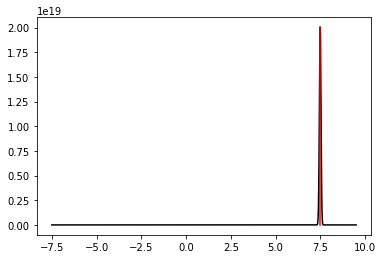

In [386]:
MK_array = np.linspace(-7.5, 9.5, 1000)
p_array = np.zeros(1000)

measured_pomega = 1/20
sig_pomega = 0.001

measured_K = 9
sig_K = 0.01

est_Mk = measured_K + 5 * np.log10(measured_pomega) + 5 - 0.0

for i, Mk in enumerate(MK_array):
    prob = np.exp(ln_posterior_Mk_given_K_pomega_Ak(Mk, measured_K, measured_pomega, sig_K, sig_pomega, Ak=0.0, L=200))
    p_array[i] = prob
    
plt.plot(MK_array, p_array, 'k-')
plt.plot([est_Mk, est_Mk], [0, max(p_array)], 'r-')

In [387]:
mean = quad(lambda MkMk: MkMk * np.exp(ln_posterior_Mk_given_K_pomega_Ak(MkMk, measured_K, measured_pomega, sig_K, sig_pomega, Ak=0.0, L=200)), -30, 30)[0]
MKint = quad(lambda MkMk: np.exp(ln_posterior_Mk_given_K_pomega_Ak(MkMk, measured_K, measured_pomega, sig_K, sig_pomega, Ak=0.0, L=200)), -30, est_Mk)[0]
median = minimize_scalar(lambda Mk: abs(MKint + quad(lambda MkMk: np.exp(ln_posterior_Mk_given_K_pomega_Ak(MkMk, measured_K, measured_pomega, sig_K, sig_pomega, Ak=0.0, L=200)), est_Mk, Mk)[0] - 0.5), bracket=(est_Mk - 0.1, est_Mk+0.1)).x
mode = minimize_scalar(lambda MkMk: -ln_posterior_Mk_given_K_pomega_Ak(MkMk, measured_K, measured_pomega, sig_K, sig_pomega, Ak=0.0, L=200)).x

/Users/gsimonian/miniconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: divide by zero encountered in log
/Users/gsimonian/miniconda3/envs/astroconda/lib/python3.6/site-packages/scipy/optimize/optimize.py:1984: RuntimeWarning: invalid value encountered in double_scalars
  tmp1 = (x - w) * (fx - fv)
/Users/gsimonian/miniconda3/envs/astroconda/lib/python3.6/site-packages/scipy/optimize/optimize.py:1985: RuntimeWarning: invalid value encountered in double_scalars
  tmp2 = (x - v) * (fx - fw)


In [388]:
print(est_Mk)
print(mean)
print(median)
print(mode)

7.494850021680094
6.362668760115746e-45
7.03042184185166
2.6180339603380443


In [374]:
MKint = quad(lambda MkMk: np.exp(ln_posterior_Mk_given_K_pomega_Ak(MkMk, measured_K, measured_pomega, sig_K, sig_pomega, Ak=0.0, L=200)), -40, est_Mk)[0]

/Users/gsimonian/miniconda3/envs/astroconda/lib/python3.6/site-packages/ipykernel_launcher.py:20: RuntimeWarning: divide by zero encountered in log


### MCMC Play

In this section, I'll implement an MCMC method to try and calculate the same thing, but in a more robust manner.

The first step is generating the data to be used.

In [416]:
# These are the "true" model parameters
r_true = 500
Mk_true = 3
Ak_true = 0.0

# Fixed parameters
AK = 0.0
L = 200

# Uncertainties
sig_pomega = 0.001
sig_K = 0.01

# Synthetic data
np.random.seed(7282020)
obs_pomega = 1 / r_true + sig_pomega * np.random.rand(1)
obs_K = Mk_true + 5 * np.log10(r_true) - 5 + AK + sig_K * np.random.rand(1)

# Naive estimates
naive_r = 1 / obs_pomega
naive_Mk = obs_K - 5 * np.log10(naive_r) + 5 - AK

In [397]:
def log_likelihood(theta, K, pomega, K_err, pomega_err):
    '''Calculate the likelihood of the data given parameters in theta.
    
    Theta should be a tuple that unpacks to (Mk, r, Ak)'''
    Mk, r = theta
    
    ln_prob = ln_likelihood_K_pomega_given_Mk_r_Ak(K, pomega, Mk, r, K_err, pomega_err, AK)
    return ln_prob

In [398]:
def log_prior(theta):
    '''Return the prior probability for the model parameters.'''
    Mk, r = theta
    
    ln_prob = ln_prior_Mk(Mk) + ln_prior_r(r, L)
    return ln_prob

In [391]:
def log_probability(theta, K, pomega, K_err, pomega_err):
    '''Calculate the product of the likelihood and prior.'''
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, K, pomega, K_err, pomega_err)

In [423]:
pos = np.array([naive_Mk, naive_r]).T + 1e-1 * np.random.randn(32, 2)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(obs_K, obs_pomega, sig_K, sig_pomega))
sampler.run_mcmc(pos, 200000, progress=True)

100%|██████████| 200000/200000 [05:08<00:00, 649.28it/s]


State([[  4.25818121 280.16950954]
 [  3.35504215 426.05371903]
 [  2.73296739 565.64185481]
 [  3.68924255 364.34226456]
 [  3.94941794 321.77302396]
 [  3.49099585 399.7819906 ]
 [  1.55059648 980.10603727]
 [  2.50488776 629.85104621]
 [  2.92270738 514.31516041]
 [  4.26226207 280.89500565]
 [  2.34054086 673.33702362]
 [  4.62528218 237.71307654]
 [  3.73978392 353.84277043]
 [  3.69774233 366.09344335]
 [  2.49675628 631.36366157]
 [  3.6042351  381.72669661]
 [  4.13990917 293.78250322]
 [  3.30640267 433.33674024]
 [  3.29738536 436.2749183 ]
 [  1.75474939 889.54602358]
 [  3.10771031 478.74839876]
 [  3.00323223 500.64291325]
 [  2.68301204 582.07940601]
 [  4.56360224 243.73540019]
 [  3.32762165 434.2056558 ]
 [  2.17818675 727.83081725]
 [  3.54994023 389.19891907]
 [  2.93415108 512.45619926]
 [  4.34350711 268.41347025]
 [  2.28968983 695.86620005]
 [  2.04190117 778.74656627]
 [  3.05226602 491.08230461]], log_prob=[-0.26369553  0.08183012 -0.62299734  0.14862696 -0.737

Text(0.5, 0, 'step number')

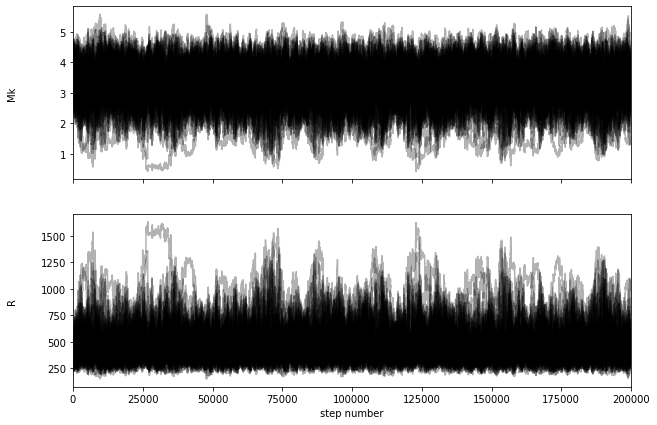

In [424]:
# This is useful to plot the chain.
fig, axes = plt.subplots(2, figsize=(10,7), sharex=True)
samples = sampler.get_chain()
labels = ["Mk", "R"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:,:,i], 'k', alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    
axes[-1].set_xlabel("step number")

In [425]:
# Calculate teh autocorrelation time to check to check the burn-in time.
tau = sampler.get_autocorr_time()
print(tau)

[1754.57073858 2125.92176295]


In [426]:
# Now get a flat sample
flat_samples = sampler.get_chain(discard=5000, thin=1000, flat=True)
print(flat_samples.shape)

(6240, 2)
